In [1]:
import pandas as pd
import numpy as np
from pycaret.classification import *

In [ ]:
df = pd.read_csv("img_path_and_clinical_info.csv")

In [ ]:
train_ids = pd.read_csv("img_path_and_clinical_info_train.csv")
train_id = train_ids["patient_id"].to_list()

In [ ]:
test_ids = pd.read_csv("img_path_and_clinical_info_test.csv")
test_id = test_ids["patient_id"].to_list()

In [10]:
print(df.columns)

Index(['Unnamed: 0', 'path', 'label_x', 'patient_id', 'local_patient_id',
       'WBC', 'PLT', 'CRP', 'T-Bil', 'AST',
       ...
       'img_feat_120', 'img_feat_121', 'img_feat_122', 'img_feat_123',
       'img_feat_124', 'img_feat_125', 'img_feat_126', 'img_feat_127', 'src',
       'label_y'],
      dtype='object', length=145)


In [11]:
df

,Unnamed: 0,path,label_x,patient_id,local_patient_id,WBC,PLT,CRP,T-Bil,AST,...,img_feat_120,img_feat_121,img_feat_122,img_feat_123,img_feat_124,img_feat_125,img_feat_126,img_feat_127,src,label_y
0,0,cropped_slices_RGB_outerline_white_fixed_margi...,0,1,1,-0.518660,0.808068,-0.684757,-0.657096,-0.317251,...,-0.084345,0.008576,0.094288,0.775329,0.281328,-0.166813,0.113900,-0.029697,cropped_slices_RGB_outerline_white_fixed_margi...,0
1,1,cropped_slices_RGB_outerline_white_fixed_margi...,0,2,2,-0.974791,0.133618,-0.691023,-0.458172,-0.356454,...,0.076673,0.264854,-0.164141,0.372486,0.418517,-0.158960,0.482768,0.113661,cropped_slices_RGB_outerline_white_fixed_margi...,0
2,2,cropped_slices_RGB_outerline_white_fixed_margi...,0,3,3,-0.049564,0.841238,-0.687890,-0.358710,-0.356454,...,1.241923,0.413503,0.481959,1.631669,0.506595,-0.054294,0.749340,-0.035336,cropped_slices_RGB_outerline_white_fixed_margi...,0
3,3,cropped_slices_RGB_outerline_white_fixed_margi...,0,4,4,-0.725313,2.002176,-0.675358,-0.856020,-0.366255,...,0.713722,0.325682,0.937974,0.159527,0.389549,-0.160898,1.343114,-0.166131,cropped_slices_RGB_outerline_white_fixed_margi...,0
4,4,cropped_slices_RGB_outerline_white_fixed_margi...,0,5,5,-0.762637,0.122562,-0.693112,-0.458172,-0.248645,...,0.322333,0.103788,0.115399,0.043568,0.036978,-0.070553,0.136491,0.261630,cropped_slices_RGB_outerline_white_fixed_margi...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,194,cropped_slices_RGB_outerline_white_fixed_margi...,1,196,96,1.490518,-1.480638,-0.616875,-0.557634,-0.238845,...,-0.031820,0.593244,0.850235,0.454047,0.050920,-0.169913,0.102287,0.298111,cropped_slices_RGB_outerline_white_fixed_margi...,1
195,195,cropped_slices_RGB_outerline_white_fixed_margi...,1,197,97,-0.632987,-0.319700,0.527720,-0.657096,0.143385,...,-0.012895,0.934404,0.347731,1.730172,0.004245,-0.164922,0.352359,0.250567,cropped_slices_RGB_outerline_white_fixed_margi...,1
196,196,cropped_slices_RGB_outerline_white_fixed_margi...,1,198,98,0.993527,0.222071,0.790893,-0.955482,-0.405458,...,-0.164799,0.552554,1.206890,1.588409,-0.146457,-0.140180,0.218259,0.203837,cropped_slices_RGB_outerline_white_fixed_margi...,1
197,197,cropped_slices_RGB_outerline_white_fixed_margi...,1,199,99,0.771551,-1.071546,1.669181,0.238062,-0.121235,...,-0.075526,0.801466,0.778098,0.964639,-0.167932,-0.161668,1.207408,0.987414,cropped_slices_RGB_outerline_white_fixed_margi...,1


In [12]:
train_df = df[df["patient_id"].isin(train_id)].copy()

In [13]:
test_df = df[df["patient_id"].isin(test_id)].copy()

In [14]:
df_estim = df.drop(
    ['Unnamed: 0', 'patient_id', 'local_patient_id', 'src', 'label_y'],
    axis=1
)

# Delete the column containing “img”
df_estim = df_estim.loc[:, ~df_estim.columns.str.contains('img')]

In [15]:
train_df = train_df.drop(
    ['Unnamed: 0', 'patient_id', 'local_patient_id', 'src', 'label_y'],
    axis=1
)

# Delete the column containing “img”
train_estim = train_df.loc[:, ~train_df.columns.str.contains('img')]

In [16]:
train_estim

,path,label_x,WBC,PLT,CRP,T-Bil,AST,ALT,γGTP,ALP,Cre,PT-INR
0,cropped_slices_RGB_outerline_white_fixed_margi...,0,-0.518660,0.808068,-0.684757,-0.657096,-0.317251,-0.319587,-0.555147,0.498105,-0.521672,-0.380524
2,cropped_slices_RGB_outerline_white_fixed_margi...,0,-0.049564,0.841238,-0.687890,-0.358710,-0.356454,-0.331034,-0.510473,-0.463694,0.216883,-0.227703
4,cropped_slices_RGB_outerline_white_fixed_margi...,0,-0.762637,0.122562,-0.693112,-0.458172,-0.248645,-0.273801,-0.130746,-0.372857,0.324964,-0.686166
7,cropped_slices_RGB_outerline_white_fixed_margi...,0,-1.247841,0.244184,-0.614786,-0.756558,0.457010,1.076890,-0.510473,-0.538500,-0.413591,-0.686166
8,cropped_slices_RGB_outerline_white_fixed_margi...,0,-1.575894,-0.463435,-0.654471,-0.955482,-0.278048,-0.216568,-0.272213,-0.602620,0.180856,-0.482405
...,...,...,...,...,...,...,...,...,...,...,...,...
193,cropped_slices_RGB_outerline_white_fixed_margi...,1,2.301810,-0.408153,1.857162,0.536449,-0.219243,-0.262354,-0.331778,0.455358,-0.251469,0.179819
194,cropped_slices_RGB_outerline_white_fixed_margi...,1,1.490518,-1.480638,-0.616875,-0.557634,-0.238845,-0.273801,-0.450908,-0.607963,1.531872,0.791103
196,cropped_slices_RGB_outerline_white_fixed_margi...,1,0.993527,0.222071,0.790893,-0.955482,-0.405458,-0.388266,-0.525365,-0.875129,9.764064,-0.074882
197,cropped_slices_RGB_outerline_white_fixed_margi...,1,0.771551,-1.071546,1.669181,0.238062,-0.121235,-0.216568,-0.346669,0.460701,2.522617,0.689222


In [21]:
test_df = test_df.drop(
    ['Unnamed: 0', 'patient_id', 'local_patient_id', 'src', 'label_y'],
    axis=1
)

# "img" を含む列を削除
test_estim = test_df.loc[:, ~test_df.columns.str.contains('img')]

In [20]:
test_estim.head()

,path,label_x,WBC,PLT,CRP,T-Bil,AST,ALT,γGTP,ALP,Cre,PT-INR
1,cropped_slices_RGB_outerline_white_fixed_margi...,0,-0.974791,0.133618,-0.691023,-0.458172,-0.356454,-0.262354,-0.413680,-0.495753,-0.053320,-0.584285
3,cropped_slices_RGB_outerline_white_fixed_margi...,0,-0.725313,2.002176,-0.675358,-0.856020,-0.366255,-0.342480,-0.436017,0.722524,-0.161401,-0.074882
5,cropped_slices_RGB_outerline_white_fixed_margi...,0,-1.116227,1.283500,-0.683713,-0.955482,-0.317251,-0.353927,-0.540256,-0.453007,-0.809889,-0.380524
6,cropped_slices_RGB_outerline_white_fixed_margi...,0,-0.149747,-0.529775,-0.490510,-0.657096,-0.307450,-0.342480,-0.532810,-0.404917,-0.539686,-0.533345
11,cropped_slices_RGB_outerline_white_fixed_margi...,0,-0.361901,0.620107,-0.689979,-0.557634,-0.297649,-0.262354,0.137298,0.407268,-0.557699,-0.074882


In [22]:
df_estim["label_x"].value_counts()

,count
label_x,
1,100
0,99


In [23]:
patient_ids = df_estim["path"].copy()
X = df_estim.drop(columns=["path"])

In [24]:
X

,label_x,WBC,PLT,CRP,T-Bil,AST,ALT,γGTP,ALP,Cre,PT-INR
0,0,-0.518660,0.808068,-0.684757,-0.657096,-0.317251,-0.319587,-0.555147,0.498105,-0.521672,-0.380524
1,0,-0.974791,0.133618,-0.691023,-0.458172,-0.356454,-0.262354,-0.413680,-0.495753,-0.053320,-0.584285
2,0,-0.049564,0.841238,-0.687890,-0.358710,-0.356454,-0.331034,-0.510473,-0.463694,0.216883,-0.227703
3,0,-0.725313,2.002176,-0.675358,-0.856020,-0.366255,-0.342480,-0.436017,0.722524,-0.161401,-0.074882
4,0,-0.762637,0.122562,-0.693112,-0.458172,-0.248645,-0.273801,-0.130746,-0.372857,0.324964,-0.686166
...,...,...,...,...,...,...,...,...,...,...,...
194,1,1.490518,-1.480638,-0.616875,-0.557634,-0.238845,-0.273801,-0.450908,-0.607963,1.531872,0.791103
195,1,-0.632987,-0.319700,0.527720,-0.657096,0.143385,0.309972,0.569145,1.230140,0.487086,-0.125823
196,1,0.993527,0.222071,0.790893,-0.955482,-0.405458,-0.388266,-0.525365,-0.875129,9.764064,-0.074882
197,1,0.771551,-1.071546,1.669181,0.238062,-0.121235,-0.216568,-0.346669,0.460701,2.522617,0.689222


In [25]:
train_patient_ids = train_estim["path"].copy()
train_X = train_estim.drop(columns=["path"])

test_patient_ids = test_estim["path"].copy()
test_X = test_estim.drop(columns=["path"])

# Comparison and Selection of Predictive Models




In [26]:
clf = setup(
    data=train_X,
    target="label_x",
    test_data=test_X,
    fold_strategy="stratifiedkfold",
    fold=5,
    session_id=42
)

,Description,Value
0,Session id,42
1,Target,label_x
2,Target type,Binary
3,Original data shape,"(199, 11)"
4,Transformed data shape,"(199, 11)"
5,Transformed train set shape,"(139, 11)"
6,Transformed test set shape,"(60, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


In [27]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9283,0.9691,0.8857,0.9714,0.9246,0.8566,0.8627,0.1760
rf,Random Forest Classifier,0.8997,0.9609,0.8857,0.9204,0.8990,0.7995,0.8060,0.2040
ada,Ada Boost Classifier,0.8995,0.9544,0.8857,0.9110,0.8979,0.7989,0.7996,0.1160
gbc,Gradient Boosting Classifier,0.8995,0.9615,0.8857,0.9159,0.8988,0.7991,0.8026,0.1520
xgboost,Extreme Gradient Boosting,0.8995,0.9608,0.8714,0.9294,0.8977,0.7991,0.8035,0.1220
lightgbm,Light Gradient Boosting Machine,0.8995,0.9604,0.9000,0.9105,0.9009,0.7991,0.8080,0.3460
nb,Naive Bayes,0.8992,0.9573,0.8714,0.9270,0.8966,0.7982,0.8023,0.0300
qda,Quadratic Discriminant Analysis,0.8849,0.9620,0.8714,0.8990,0.8828,0.7697,0.7735,0.0360
knn,K Neighbors Classifier,0.8706,0.9383,0.7571,0.9857,0.8423,0.7416,0.7698,0.0540
lr,Logistic Regression,0.8704,0.9620,0.8143,0.9258,0.8618,0.7410,0.7525,2.5840


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=42, verbose=0,
                     warm_start=False)

In [28]:
model = create_model('et')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8929,0.9541,0.7857,1.0000,0.8800,0.7857,0.8044
1,0.9286,0.9566,0.9286,0.9286,0.9286,0.8571,0.8571
2,0.9286,0.9847,0.9286,0.9286,0.9286,0.8571,0.8571
3,0.9286,0.9719,0.8571,1.0000,0.9231,0.8571,0.8660
4,0.9630,0.9780,0.9286,1.0000,0.9630,0.9260,0.9286
Mean,0.9283,0.9691,0.8857,0.9714,0.9246,0.8566,0.8627
Std,0.0222,0.0119,0.0571,0.0350,0.0264,0.0444,0.0395


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [29]:
tuned_model = tune_model(model, n_iter = 15, optimize = 'f1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8929,0.9592,0.7857,1.0000,0.8800,0.7857,0.8044
1,0.8929,0.9388,0.7857,1.0000,0.8800,0.7857,0.8044
2,0.9286,0.9898,0.9286,0.9286,0.9286,0.8571,0.8571
3,0.9286,0.9847,0.8571,1.0000,0.9231,0.8571,0.8660
4,0.9259,0.9670,0.8571,1.0000,0.9231,0.8525,0.8619
Mean,0.9138,0.9679,0.8429,0.9857,0.9069,0.8276,0.8388
Std,0.0171,0.0184,0.0535,0.0286,0.0221,0.0343,0.0282


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 15 candidates, totalling 75 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [30]:
evaluate_model(tuned_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9167,0.9494,0.9000,0.9310,0.9153,0.8333,0.8338


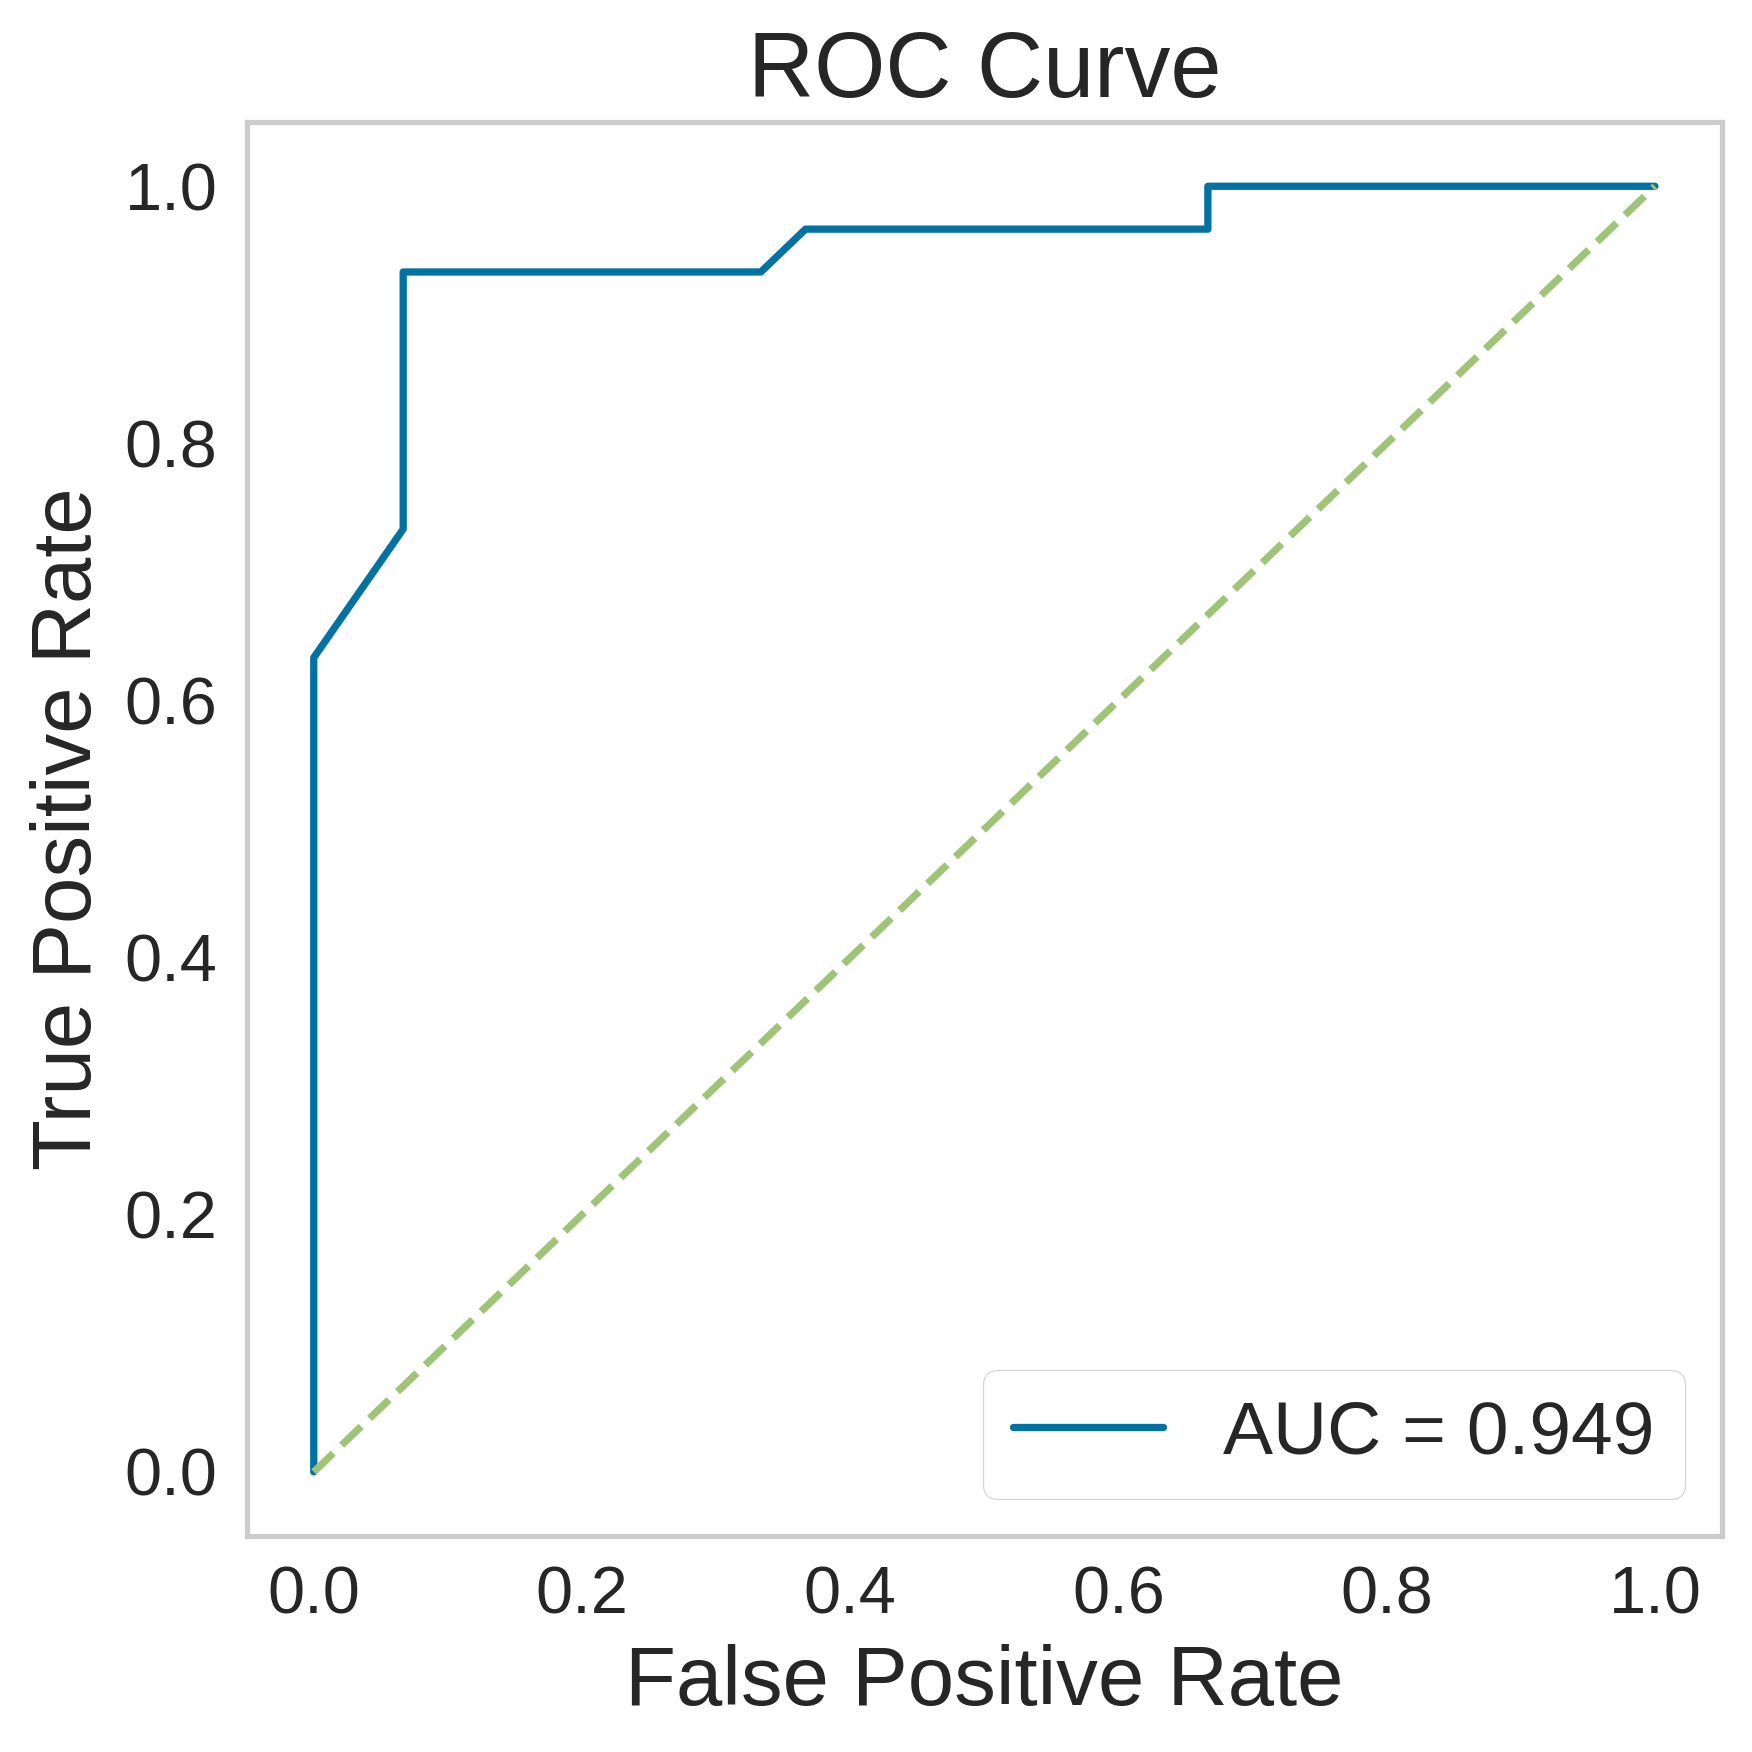

In [31]:
from pycaret.classification import predict_model
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# ===== test prediction =====
pred = predict_model(tuned_model, raw_score=True)


y_true = pred["label_x"]
y_score = pred["prediction_score_1"]

# ===== ROC =====
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# ===== plot =====
plt.figure(figsize=(6,6), dpi=300)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate", fontsize=20)
plt.ylabel("True Positive Rate", fontsize=20)
plt.title("ROC Curve", fontsize=22)
plt.tick_params(axis='both', labelsize=16)
plt.legend(fontsize=18, loc="lower right", frameon=True)
plt.grid()

plt.tight_layout()
plt.show()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9167,0.9494,0.9000,0.9310,0.9153,0.8333,0.8338


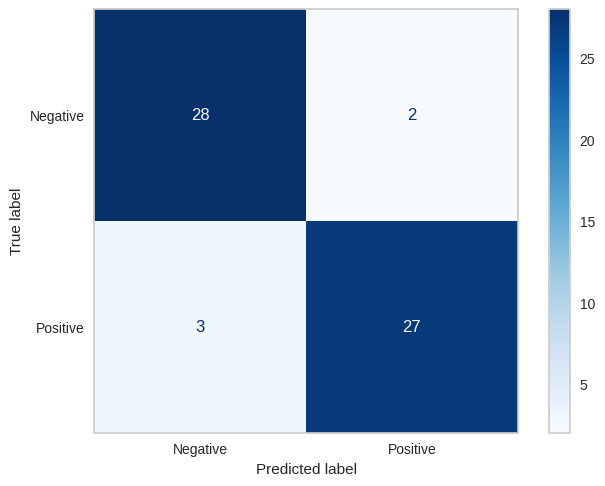

In [32]:
from pycaret.classification import predict_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions using the PyCaret model
pred_df = predict_model(tuned_model)

# Extract true labels and predicted labels
y_true = pred_df["label_x"]        # Ground truth labels
y_pred = pred_df["prediction_label"]

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix (consistent with your style)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive'],
)

disp.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

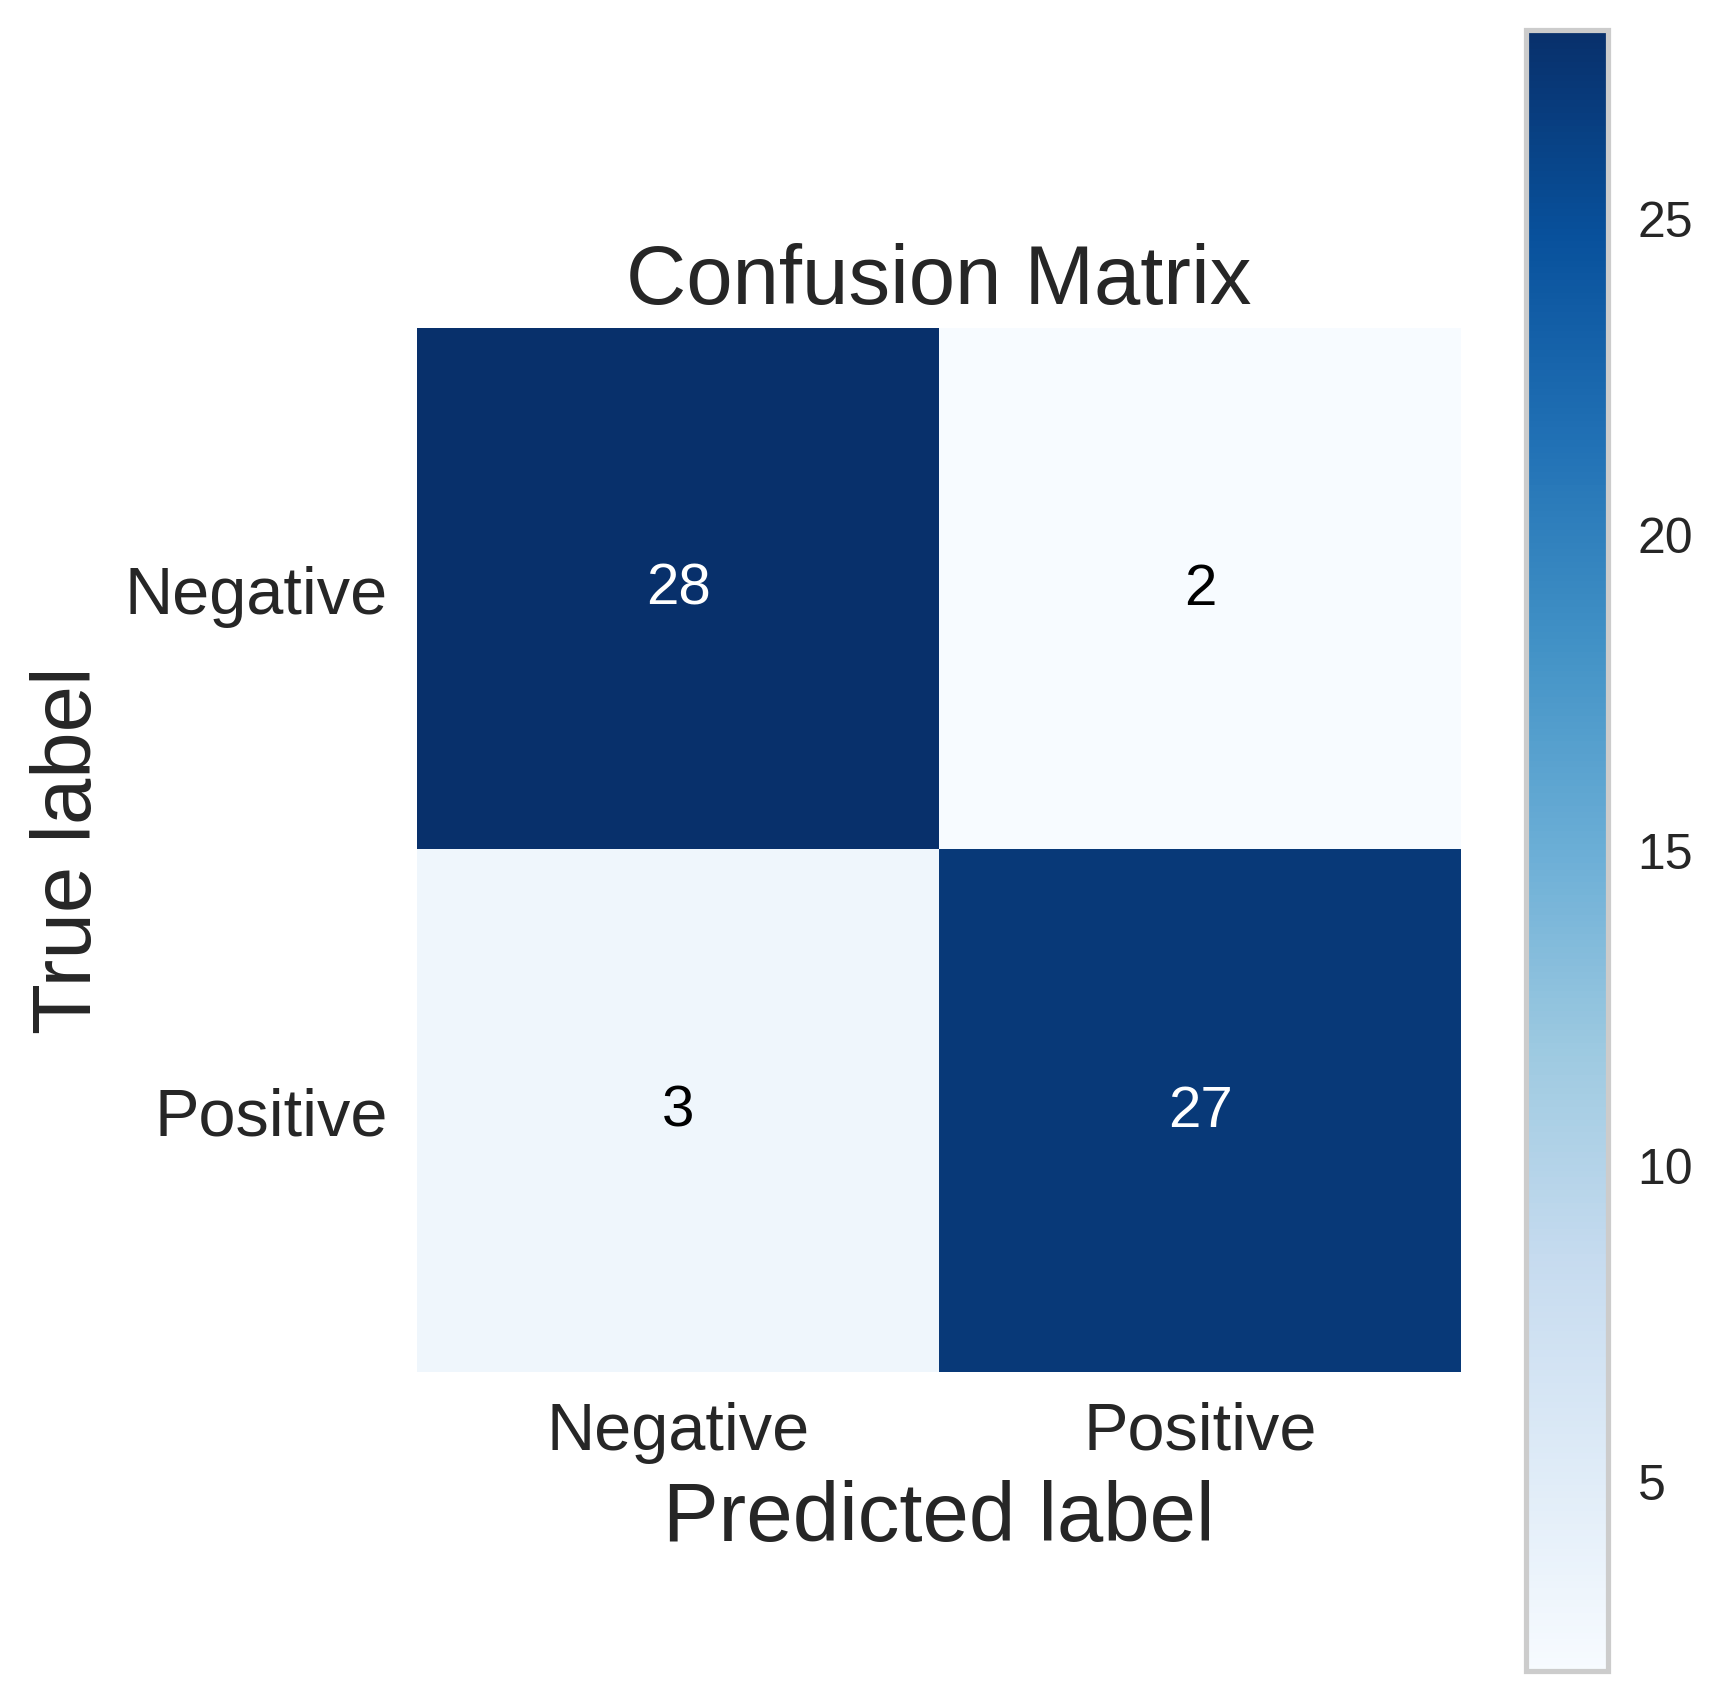

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# ===== confusion matrix =====
cm = confusion_matrix(y_true, y_pred)

# ===== figure =====
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# ===== heatmap =====
im = ax.imshow(cm, cmap=plt.cm.Blues)

# ===== text =====
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black",
            fontsize=14
        )


ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'], fontsize=16)
ax.set_yticklabels(['Negative', 'Positive'], fontsize=16)

ax.set_xlabel("Predicted label", fontsize=20)
ax.set_ylabel("True label", fontsize=20)

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=12)

ax.set_title("Confusion Matrix", fontsize=20)

plt.tight_layout()
plt.show()

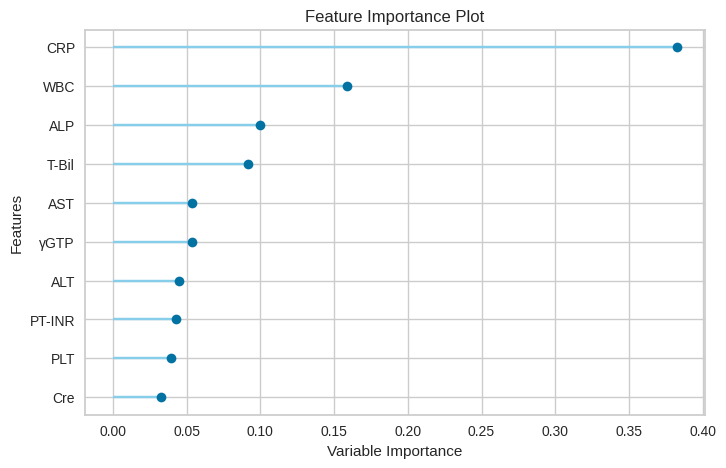

In [34]:
plot_model(tuned_model, plot="feature")

In [35]:
# 1) Finalize the model by retraining it on the full dataset
model_final = finalize_model(tuned_model)

# 2) Access the underlying Random Forest classifier from the pipeline
rf = model_final.named_steps["actual_estimator"]

# 3) Obtain the feature names used during model training
feature_names = get_config("X_train").columns

# 4) feature importance
fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(fi.head(20))

,Feature,Importance
2,CRP,0.369398
0,WBC,0.155330
3,T-Bil,0.097292
7,ALP,0.093514
4,AST,0.058885
9,PT-INR,0.055109
6,γGTP,0.049722
5,ALT,0.048928
1,PLT,0.043463
8,Cre,0.028360


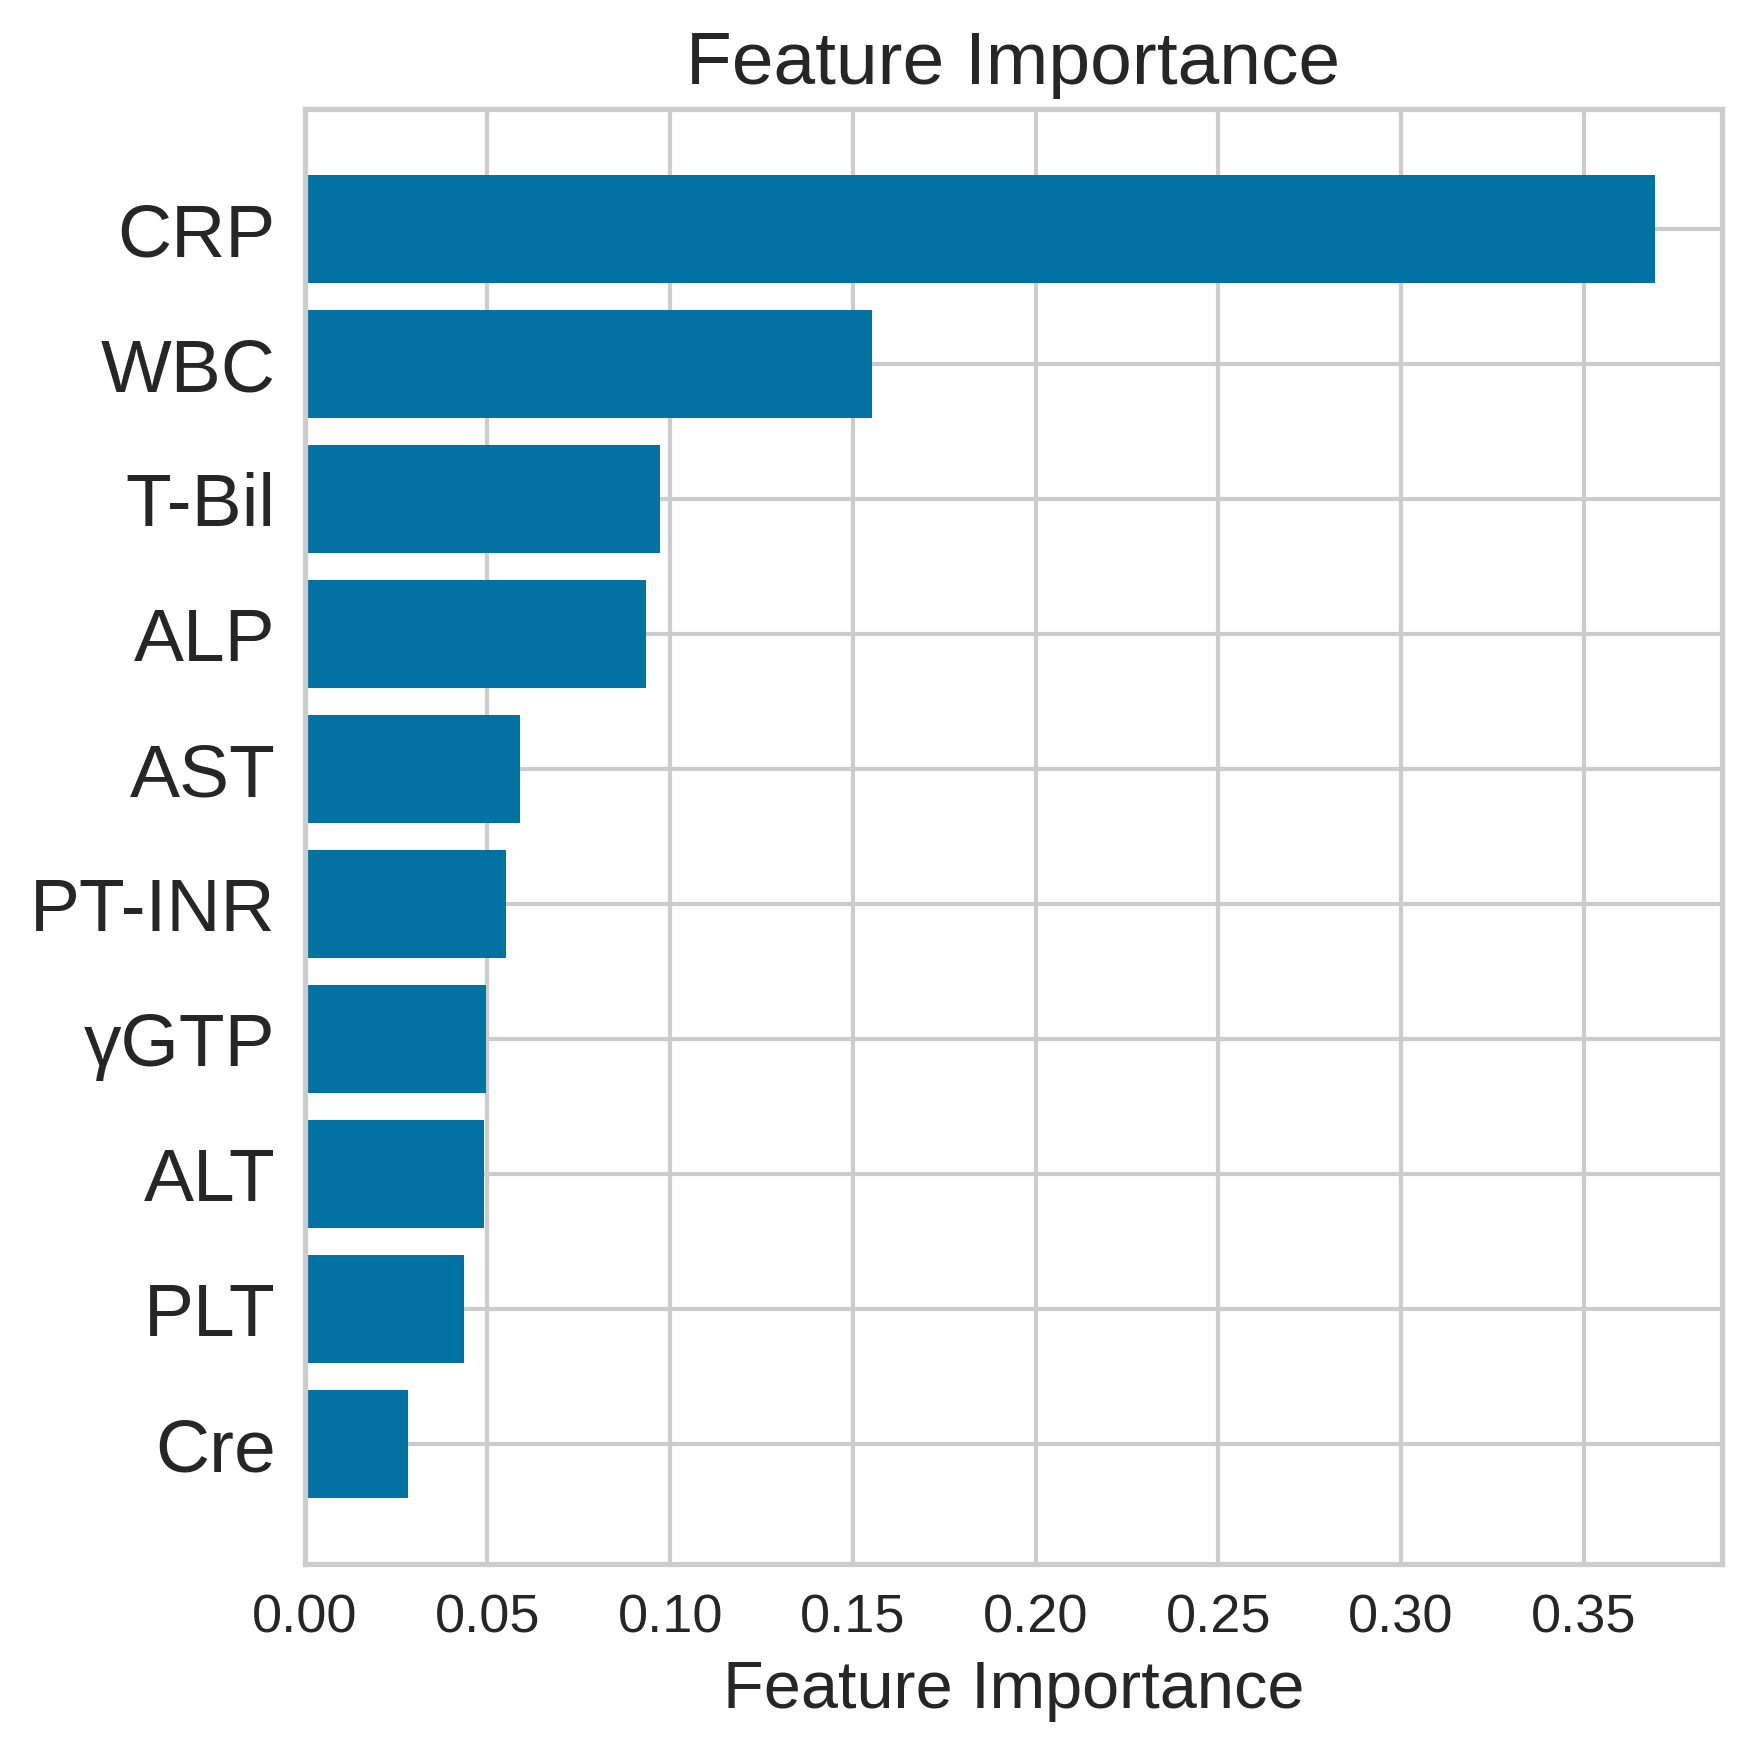

In [36]:
import matplotlib.pyplot as plt

# ===== sort =====
fi_plot = fi.sort_values("Importance", ascending=True)

# ===== plot =====
plt.figure(figsize=(6, 6), dpi=300)

plt.barh(fi_plot["Feature"], fi_plot["Importance"])

plt.xlabel("Feature Importance", fontsize=16)
plt.title("Feature Importance", fontsize=18)

plt.xticks(fontsize=13)
plt.yticks(fontsize=18)

plt.tight_layout()
plt.show()